In [198]:
from arcgis.gis import GIS
from arcgis.apps.itemgraph import ItemGraph, create_dependency_graph

<User username:tkinlaw_EsriEdDelivery>
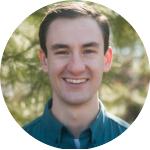

In [199]:
gis = GIS('Home')
gis.users.me

<Item title:"Metro_Stations_Regional" type:Feature Layer Collection owner:tkinlaw_EsriEdDelivery>
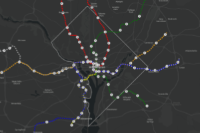

In [200]:
metroId = 'b79a004c632e425483ffdf2761d9d88b'
targetItem = gis.content.get(metroId)
targetItem

In [203]:
fldrItems = []
for folder in gis.users.me.folders:
    if folder.name == "FedGIS 2026":
        for item in folder.list():
            fldrItems.append(item)
print(f"There are {len(fldrItems)} item(s) in this folder")

There are 23 item(s) in this folder


In [204]:
graph = create_dependency_graph(gis, fldrItems, include_reverse=True)
graph

In [205]:
graph.all_items(out_format="item")

[<Item title:"Interstate_Highways" type:Service Definition owner:tkinlaw_EsriEdDelivery>,
 <Item title:"Interstate_Highways" type:Feature Layer Collection owner:tkinlaw_EsriEdDelivery>,
 <Item title:"DC Parcels" type:Web Map owner:tkinlaw_EsriEdDelivery>,
 <Item title:"World Topographic Map" type:Vector Tile Layer owner:esri_vector>,
 <Item title:"Parcel Lots" type:Feature Layer Collection owner:DCGISopendata>,
 <Item title:"Population_and_Employment_Forecasts" type:Shapefile owner:tkinlaw_EsriEdDelivery>,
 <Item title:"Population_and_Employment_Forecasts" type:Feature Layer Collection owner:tkinlaw_EsriEdDelivery>,
 <Item title:"DC Population and Employment Forecasts" type:Web Map owner:tkinlaw_EsriEdDelivery>,
 <Item title:"DC Public Schools" type:Shapefile owner:tkinlaw_EsriEdDelivery>,
 <Item title:"DC Public Schools" type:Web Map owner:tkinlaw_EsriEdDelivery>,
 <Item title:"Crime_Incidents_in_2020" type:Feature Layer Collection owner:tkinlaw_EsriEdDelivery>,
 <Item title:"Crime_In

In [206]:
targetNode = graph.get_node(targetItem.id)
targetNode

ItemNode(id: b79a004c632e425483ffdf2761d9d88b, item: Metro_Stations_Regional)

In [207]:
nodes = targetNode.contains()
if nodes:
    print(f"This item contains {len(nodes)} item(s):")
    for node in nodes:
        print("\t", node.item.title, "(" + node.item.type + ")")
else:
    print("This item does not contain other items directly.")

This item contains 1 item(s):
	 Metro_Stations_Regional (Service Definition)


In [208]:
nodes = targetNode.requires()
if nodes:
    print(f"This item requires {len(nodes)} item(s):")
    for node in nodes:
        print("\t", node.item.title, "(" + node.item.type + ")")
else:
    print("This item requires no items. It does not have deep dependencies.")

This item requires 1 item(s):
	 Metro_Stations_Regional (Service Definition)


In [209]:
nodes = targetNode.contained_by()
if nodes:
    print(f"This item is contained by {len(nodes)} item(s):")
    for node in nodes:
        print("\t", node.item.title, "(" + node.item.type + ")")
else:
    print("This item is not contained by other items. It is not a dependency.")

This item is contained by 1 item(s):
	 DC Transportation FedGIS 2026 (Web Map)


In [210]:
nodes = targetNode.required_by()
if nodes:
    print(f"This item is a deep dependency and required by {len(nodes)} item(s):")
    for node in nodes:
        print("\t", node.item.title, "(" + node.item.type + ")")
else:
    print("This item is not required by any items. It is not a deep dependency.")

This item is a deep dependency and required by 4 item(s):
	 DC Transportation Experience_finished (Web Experience)
	 DC Transportation - Web AppBuilder (Web Mapping Application)
	 DC Transportation FedGIS 2026 (Web Map)
	 DC Transportation Experience_fullmode (Web Experience)
